# Trajectories | Trial Trajectory
-----------------------------------------

Select the same protocol-filtered trial rows and outbound/inbound phase boundaries used by the spatial guide. The plotting function draws already-sliced paths with movement; it does not perform trial selection.

## Setup and Configuration

In [43]:
##### Imports ##########################################################################

#==== Generic Imports ==================================================================
from pathlib import Path
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

#==== Movement Imports =================================================================
import movement.kinematics
import movement.utils.vector

#==== Data-Conduit Imports =============================================================
from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from data_conduit.integrations.DLC.pose import pose_to_movement
from data_conduit.refactor_qc import (
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    filter_trials,
)

#==== Figure-Project Imports ===========================================================
from movement_figures.data_template.loading import build_datastructure
from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from movement_figures.timeseries_template.annotations import (
    AnnotationResult,
    annotate_qc_timeseries,
)

import movement.plots
from movement_figures.video import read_session_video_frame



#### Notebook Settings #################################################################

pd.set_option("display.max_columns", None)                                          # Changes default pandas display settings to show all columns in a dataframe.
pd.set_option("display.max_rows", None)                                             # Changes default pandas display settings to show all rows in a dataframe.

In [44]:
##### Setup Parameters #################################################################

# === 1| Select Mice, Days and Recording Folders Before Reading Files =============
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                                       # Example choices belong here: l0_selector and l1_selector.
# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                                # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                            # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                        # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                          # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering.


In [45]:
##### Load DataStructure ###############################################################

#=== Load data ========================================================================

fig_ds_obj = build_datastructure(
    root               = ROOT,                                                                 # Directory above the named hierarchy levels.
    level_names        = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams            = ("trials", "session_settings", "video", "dlc"),                       # Data streams to be included in the datastructure.
    include            = None,                                                                 # Keep these session folder names; None keeps all.
    exclude            = None,                                                                 # Alternatively omit these session folder names.
    raw_events         = True,                                                                 # Convenience alias for adding "events" to the requested sources.
    device_yaml        = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml     = "./soundcard.yml",                                                    # Lab SoundCard register definitions.
    nosepoke_count     = 18,                                                                   # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                                  # Preserve the existing lab parser setting.
    dlc_file_format     = "auto",                                                              # Existing reader prefers CSV, otherwise HDF5.
    trial_spec = None,                                                                         # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.
    
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds_obj.select()
streams = fig_ds_obj.load()                                                                    # Load is required to access the selected streams.

#=== Create convenient compact trial dataframe without some unnecessary columns. ======
streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                                                   # Whether to modify the trial dataframe in place or return a new dataframe. 
)
'''More useful for visual inspection and analysis. 
Check the misc.py file for the default columns to keep and drop.'''


#=== Apply Trial Filtering Protocol to construct new stream objects ===================

# Full filtered trials
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

# Filtered compact trials 
streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"],   
                #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], 
                 #selectors={"session": session_id}
    ),
)

#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,                                                                # Loaded dataset object containing all streams of interest.
    show_stream_shapes = True,                                                                 # Whether to display the shapes of the streams.
    show_stream_dtypes = True,                                                                 # Whether to display the data types of the streams.
    display_streams = False                                                                    # Whether to display the actual stream data as a table.
)



     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


## Select the Recording and Trials

In [46]:
##### Trial Selection ##################################################################

#==== Extract Trial Range ============
selected_trials = slice_stream(streams['filtered_trials'][:4])              # Select the first n trials

#==== Extract Recording Identifier ===
sessionID = selected_trials['session'].unique().item()                      # Extract unique sID from selected trials, remove duplicates, ensure single value.

#==== Select Tracked Positions =======
recording = slice_stream(stream = streams['dlc:movement'],                  # selectors{} here keeps movement data belonging to the specified session only.
                        selectors = {'session' : sessionID }, 
)

position = recording['position']                                            # ['position'] extracts positional data from the movement stream.

position = position.sel(individual='individual_0',                          # .sel() selects the specified individual from the positional data.
                        drop=True,                                          # drop=True removes the individual dimension from the resulting DataArray, but leaves other dims intact.
)


## Slice Outbound and Inbound Positions

In [47]:
##### Select the Body Trajectory for Each Trial Phase ###################################

body_position = position.sel(keypoint="body", drop=True)

whole = slice_stream_per_trial(
    stream=body_position,
    trials=selected_trials,
    segment="trial",
    time_coord="time",
)

outbound = slice_stream_per_trial(
    stream=body_position, trials=selected_trials, segment="outbound", time_coord="time",
)

inbound = slice_stream_per_trial(
    stream=body_position, trials=selected_trials, segment="inbound", time_coord="time",
)

In [48]:
##### Read the Matching Video Background ################################################

background_frame, video_path = read_session_video_frame(
    fig_ds_obj.sessions[sessionID].path,                     # Same recording and undistorted pixel coordinates as position.
)

## Trial Trajectory Plotting Function

API: [plot_centroid_trajectory](https://movement.neuroinformatics.dev/latest/api/movement.plots.plot_centroid_trajectory.html). The body point is selected before the call, so this does not average different keypoints.

In [49]:
##### Plot a Trial Trajectory on Ax #####################################################


def plot_ax_trial_trajectory(
    ax: plt.Axes,
    trajectory: xr.DataArray,
    background_frame: np.ndarray | None = None,
    subtitle: str | None = "Trial Trajectory",
    **kwargs,
) -> plt.Axes:
    """Draw one already-selected trajectory using movement's trajectory plotter.

    Parameters
    ----------
    ax : plt.Axes
        Axis on which to draw the trajectory.
    trajectory : xr.DataArray
        Position samples with dimensions (time, space), x/y pixels and recording
        seconds. Select the individual, body point and phase before calling.
    background_frame : np.ndarray or None
        Matching unscaled video frame. None draws the trajectory without an image.
    subtitle : str or None
        Panel title; None leaves the title unchanged.
    **kwargs
        Passed to movement.plots.plot_centroid_trajectory, e.g. s, alpha or c.
        With no c argument, movement colours points by recording time.

    Returns
    -------
    plt.Axes
        Supplied axis containing the trajectory. Missing samples are not connected.
    """
    #==== 1| Put the Trajectory in the Matching Video Coordinates =========================
    if background_frame is not None:
        height, width = background_frame.shape[:2]
        extent = (-0.5, width - 0.5, height - 0.5, -0.5)
        ax.imshow(background_frame, origin="upper", extent=extent, alpha=0.55)

    #==== 2| Let movement Draw the Already-Selected Body Point ============================
    movement.plots.plot_centroid_trajectory(da=trajectory, ax=ax, **kwargs)

    #==== 3| Keep x/y Pixels and a Downward-Positive Image y Axis ==========================
    ax.set(xlabel="x (Pixels)", ylabel="y (Pixels)", aspect="equal")
    if background_frame is not None:
        ax.set(xlim=extent[:2], ylim=extent[2:])
    elif not ax.yaxis_inverted():
        ax.invert_yaxis()
    if subtitle is not None:
        ax.set_title(subtitle)
    return ax

## Generate Single-Trial Figures

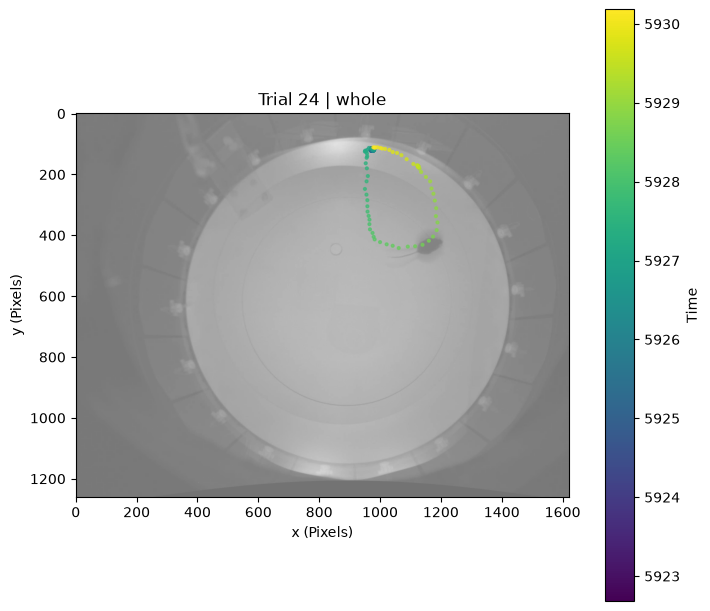

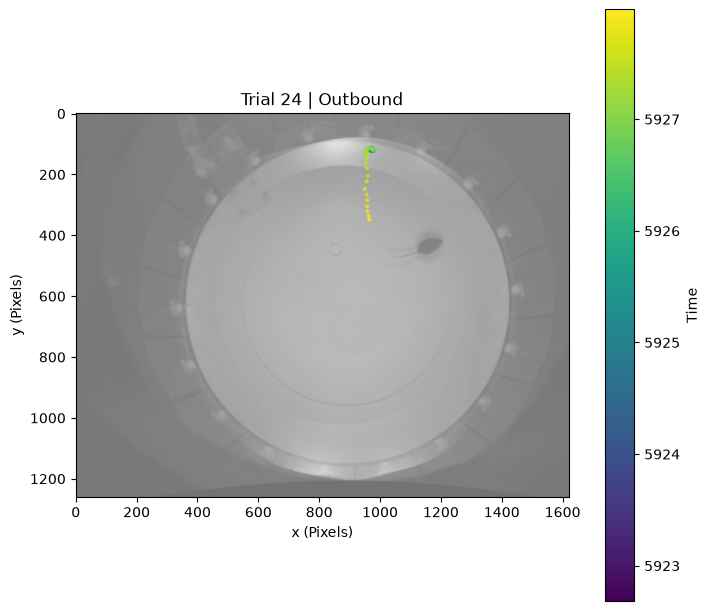

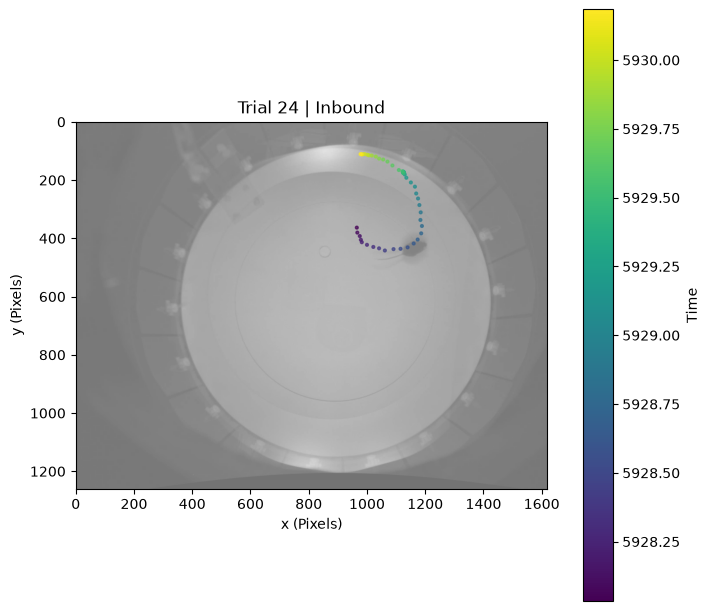

In [50]:
SINGLE_TRIAL_ROW = 0
trial_index = selected_trials.iloc[SINGLE_TRIAL_ROW]["trial_index"]

trajectories = {
    'whole': whole[SINGLE_TRIAL_ROW],
    "Outbound": outbound[SINGLE_TRIAL_ROW],
    "Inbound": inbound[SINGLE_TRIAL_ROW],
}

for phase, trajectory in trajectories.items():
    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")

    plot_ax_trial_trajectory(
        ax=ax,
        trajectory=trajectory,
        background_frame=background_frame,
        subtitle=f"Trial {trial_index} | {phase}",
        s=4,
        alpha=0.7,
    )

    plt.show()

    # filename = f"trial_{trial_index}_{phase.lower()}"
    # fig.savefig(f"{filename}.png", dpi=200, bbox_inches="tight")
    # fig.savefig(f"{filename}.svg", bbox_inches="tight")

    # plt.show()

## Generate Multi-Trial Figures

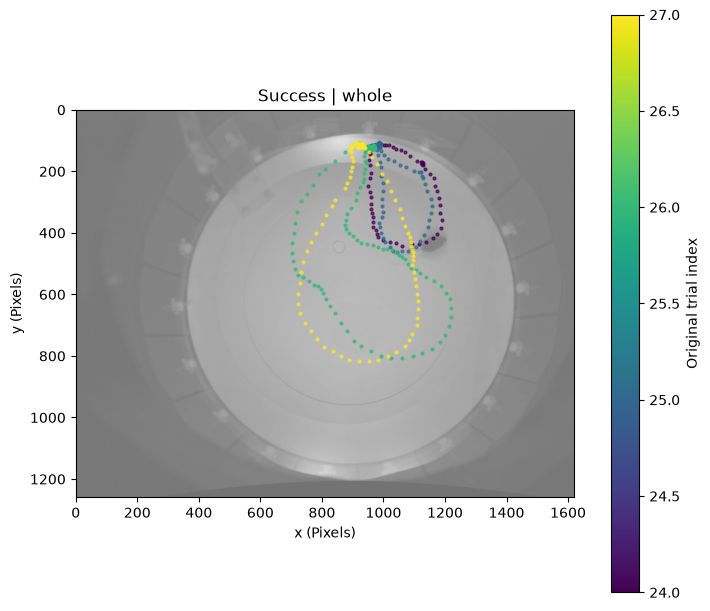

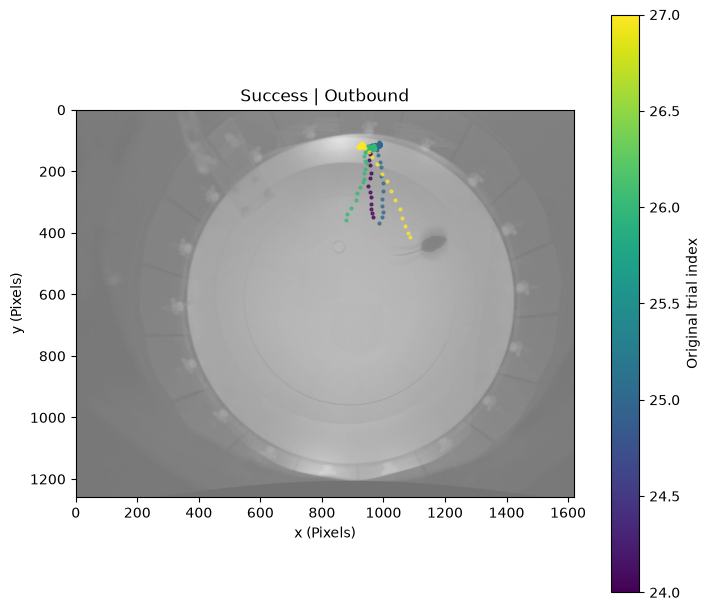

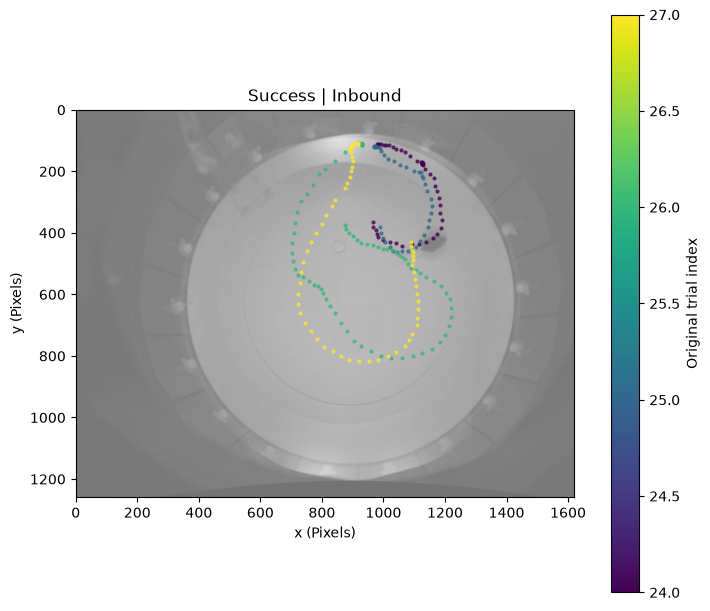

In [ ]:
##### Prepare Groups, Colours and Phases ################################################

outcome_rows = selected_trials.groupby(
    "outcome", sort=False, observed=True,
).indices

trial_numbers = selected_trials["trial_index"].to_numpy()
colour_scale = plt.Normalize(trial_numbers.min(), trial_numbers.max())
colour_map = plt.get_cmap("viridis")
trial_colours = colour_map(colour_scale(trial_numbers))

phases = {
    'whole': whole,
    "Outbound": outbound,
    "Inbound": inbound,
}

##### Plot Each Outcome and Phase ######################################################

for outcome, rows in outcome_rows.items():
    for phase, paths in phases.items():
        fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")

        frame = background_frame
        for row in rows:
            plot_ax_trial_trajectory(
                ax               = ax,
                trajectory       = paths[row],
                background_frame = frame,
                subtitle         = f"{outcome} | {phase}",
                c                = [trial_colours[row]],
                s                = 4,
                alpha            = 0.7,
            )
            frame = None  # Draw the background only for the first trajectory.

        fig.colorbar(
            plt.cm.ScalarMappable(norm=colour_scale, cmap=colour_map),
            ax=ax,
            label="Original trial index",
        )

        # filename = f"trajectories_{outcome.lower()}_{phase.lower()}.svg"
        # fig.savefig(filename, bbox_inches="tight")
        plt.show()

    print('check that outbound and inbound labels are the right way around')